<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/SegundoParcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mineria de Datos


## Segundo Parcial

Programación para ciencia de datos:

In [ ]:
import pandas as pd
df_data = {"species" : ["vulture", "guineafowl", "red-legged patridge"], "neck vertebrate" : [13,14,14] }
df = pd.DataFrame(df_data)
df

,species,neck vertebrate
0,vulture,13
1,guineafowl,14
2,red-legged patridge,14


### Introducing Scikit-Learn

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris ["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
X = iris.drop("species", axis=1)
Y = iris["species"]
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Data as table

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Target array

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


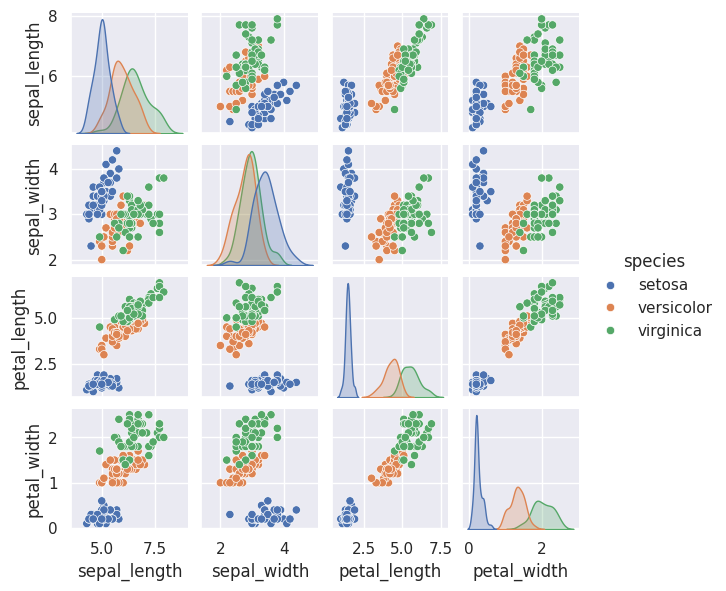

In [ ]:
%matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', size=1.5);

In [ ]:
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [ ]:
y_iris = iris['species']
y_iris.shape

(150,)

Regresion lineal

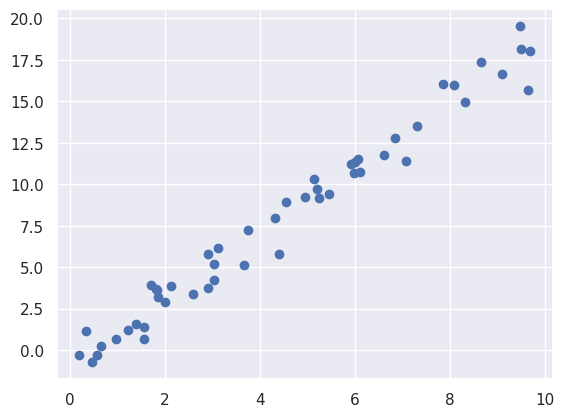

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y);

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression(fit_intercept=True)
model

LinearRegression()

In [ ]:
X = x[:, np.newaxis]
X.shape

(50, 1)

In [ ]:
model.fit(X, y)

LinearRegression()

In [ ]:
model.coef_

array([1.9776566])

In [ ]:
model.intercept_

np.float64(-0.9033107255311146)

In [ ]:
xfit = np.linspace(-1, 11)
xfit

array([-1.        , -0.75510204, -0.51020408, -0.26530612, -0.02040816,
        0.2244898 ,  0.46938776,  0.71428571,  0.95918367,  1.20408163,
        1.44897959,  1.69387755,  1.93877551,  2.18367347,  2.42857143,
        2.67346939,  2.91836735,  3.16326531,  3.40816327,  3.65306122,
        3.89795918,  4.14285714,  4.3877551 ,  4.63265306,  4.87755102,
        5.12244898,  5.36734694,  5.6122449 ,  5.85714286,  6.10204082,
        6.34693878,  6.59183673,  6.83673469,  7.08163265,  7.32653061,
        7.57142857,  7.81632653,  8.06122449,  8.30612245,  8.55102041,
        8.79591837,  9.04081633,  9.28571429,  9.53061224,  9.7755102 ,
       10.02040816, 10.26530612, 10.51020408, 10.75510204, 11.        ])

In [ ]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

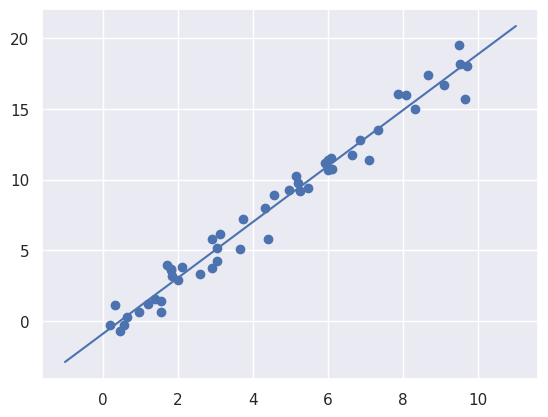

In [ ]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                random_state=1)

In [ ]:
from sklearn.naive_bayes import GaussianNB # 1. choose model class
model = GaussianNB()                       # 2. instantiate model
model.fit(Xtrain, ytrain)                  # 3. fit model to data
y_model = model.predict(Xtest)             # 4. predict on new data

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.9736842105263158

Unsupervised learning example: Iris dimensionality

In [ ]:
from sklearn.decomposition import PCA  # 1. Choose the model class
model = PCA(n_components=2)            # 2. Instantiate the model with hyperparameters
model.fit(X_iris)                      # 3. Fit to data. Notice y is not specified!
X_2D = model.transform(X_iris)         # 4. Transform the data to two dimensions

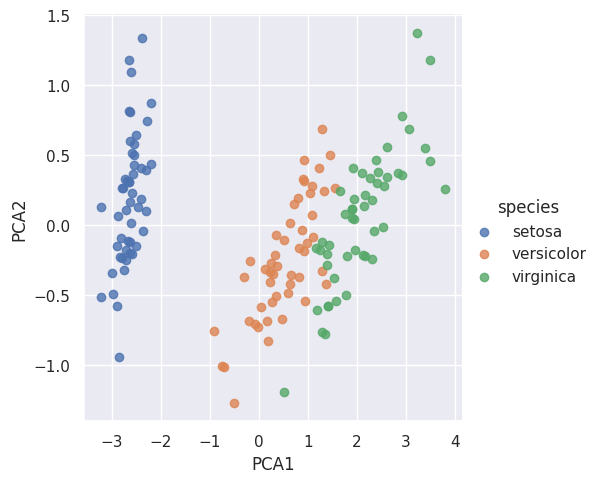

In [ ]:
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]
sns.lmplot(x="PCA1", y="PCA2", hue='species', data=iris, fit_reg=False);

In [ ]:
from sklearn.mixture import GaussianMixture  # 1. Choose the model class
model = GaussianMixture(n_components=3,
            covariance_type='full')  # 2. Instantiate the model with hyperparameters
model.fit(X_iris)                    # 3. Fit to data. Notice y is not specified!
y_gmm = model.predict(X_iris)        # 4. Determine cluster labels

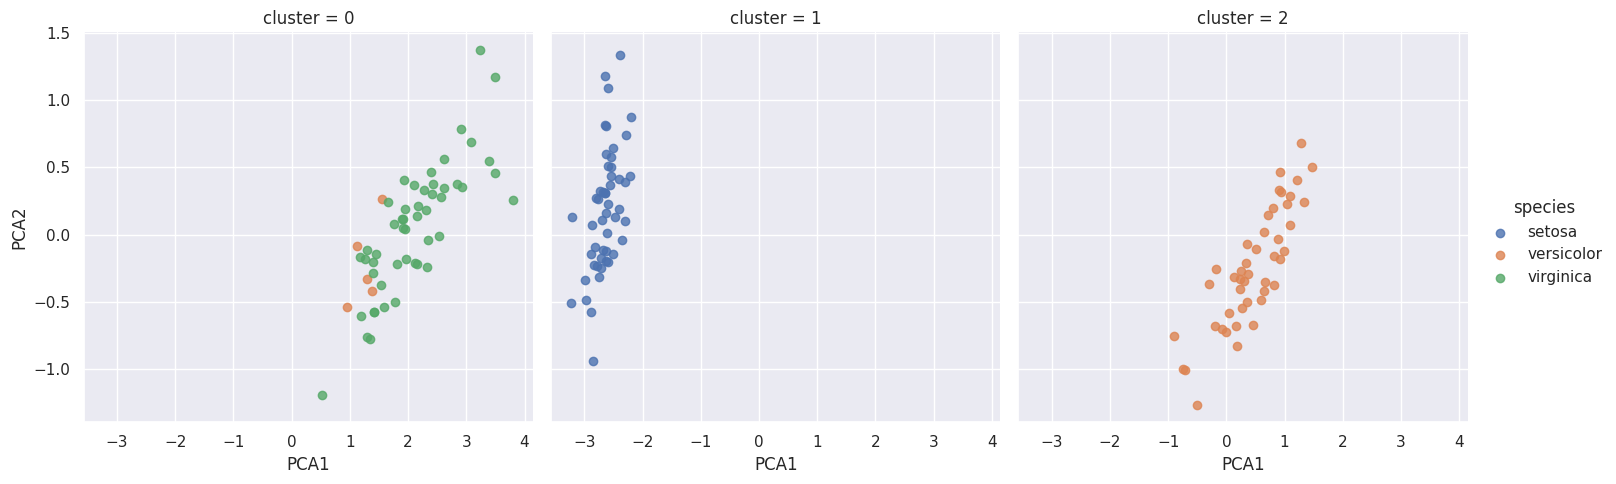

In [ ]:
iris['cluster'] = y_gmm
sns.lmplot(x='PCA1', y='PCA2', data=iris, hue='species',
           col='cluster', fit_reg=False);

Application: Exploring Hand-written Digits

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

(1797, 8, 8)

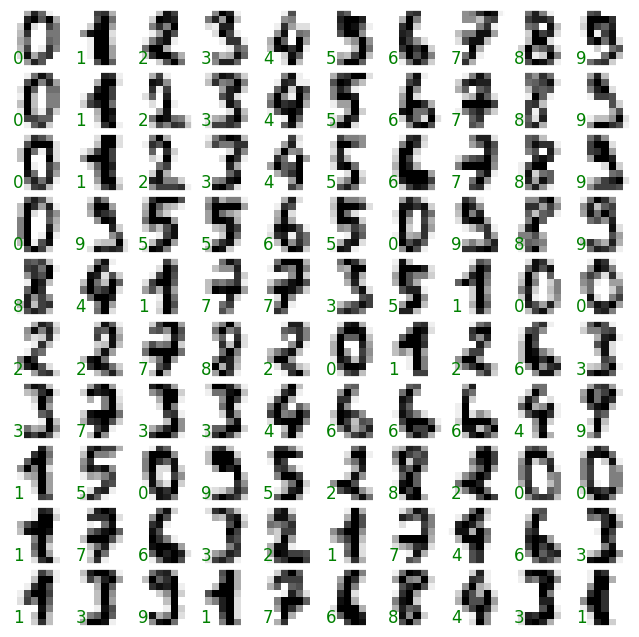

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In [ ]:
X = digits.data
X.shape

(1797, 64)

In [ ]:
y = digits.target
y.shape

(1797,)

In [ ]:
from sklearn.manifold import Isomap
iso = Isomap(n_components=2)
iso.fit(digits.data)
data_projected = iso.transform(digits.data)
data_projected.shape

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)

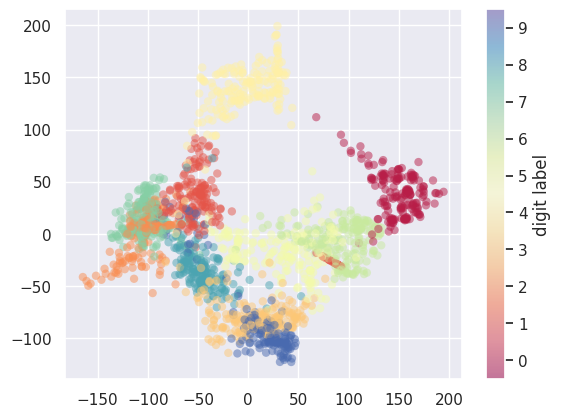

In [ ]:
plt.scatter(data_projected[:, 0], data_projected[:, 1], c=digits.target,
            edgecolor='none', alpha=0.5,
            cmap=plt.colormaps['Spectral'])
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5, 9.5);

Classification on digits

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.8333333333333334

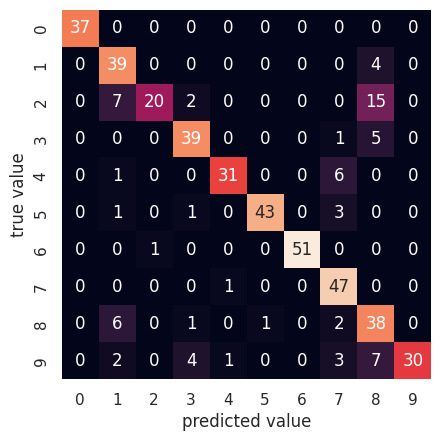

In [ ]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value');

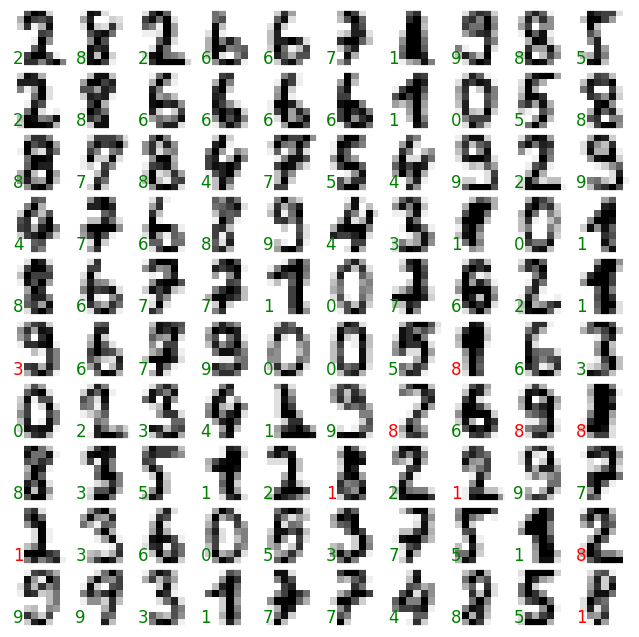

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

test_images = Xtest.reshape(-1, 8, 8)

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(y_model[i]),
            transform=ax.transAxes,
            color='green' if (ytest[i] == y_model[i]) else 'red')

### Hyperparameters and Model Validation

Model Validation the wrong way



In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=1)

In [ ]:
model.fit(X, y)
y_model = model.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_model)

1.0

Model Validation the good way

In [ ]:
from sklearn.model_selection import train_test_split
# split the data with 50% in each set
X1, X2, y1, y2 = train_test_split(X, y, random_state=0,
                                  train_size=0.5)

# fit the model on one set of data
model.fit(X1, y1)

# evaluate the model on the second set of data
y2_model = model.predict(X2)
accuracy_score(y2, y2_model)

0.9066666666666666

Model validation via cross-validation

In [ ]:
y2_model = model.fit(X1, y1).predict(X2)
y1_model = model.fit(X2, y2).predict(X1)
accuracy_score(y1, y1_model), accuracy_score(y2, y2_model)

(0.96, 0.9066666666666666)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

In [ ]:
from sklearn.model_selection import LeaveOneOut
scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
scores.mean()

np.float64(0.96)

### Selecting the Best Model

The Bias-variance trade-off

Validation curves in Scikit-Learn

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

In [ ]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

X, y = make_data(40)

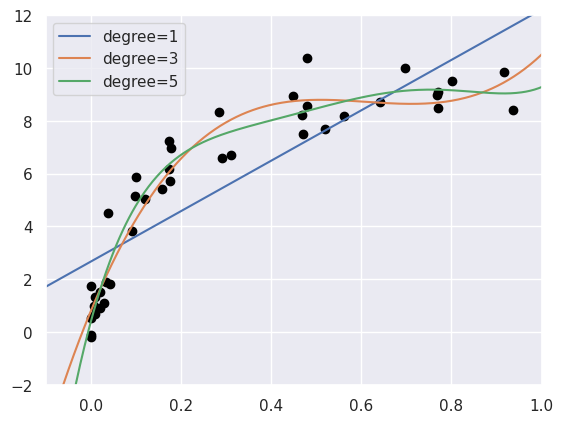

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()  # plot formatting

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 5]:
    y_test = PolynomialRegression(degree).fit(X, y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

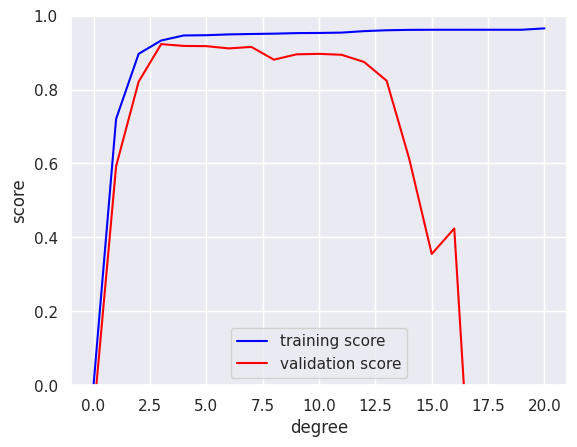

In [ ]:
from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(PolynomialRegression(), X, y,
                                          param_name='polynomialfeatures__degree', param_range=degree, cv=7)

plt.plot(degree, np.median(train_score, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

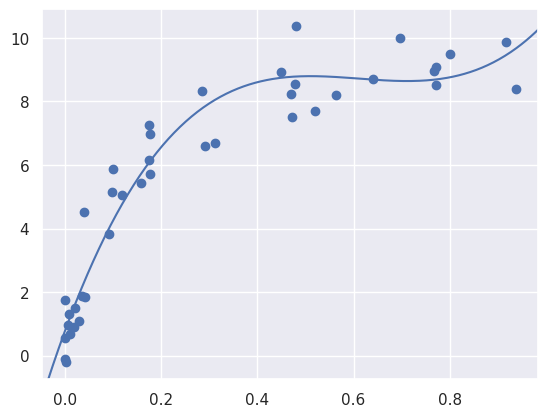

In [ ]:
plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = PolynomialRegression(3).fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test);
plt.axis(lim);

Learning Curves

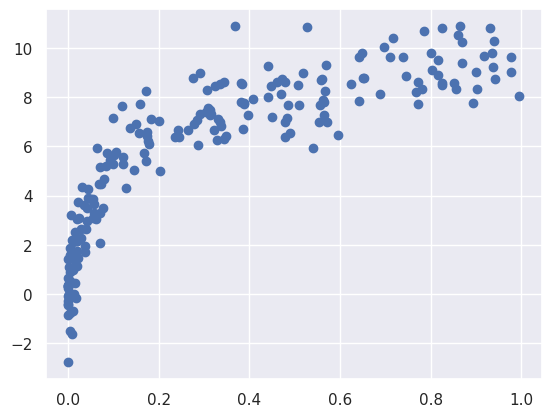

In [ ]:
X2, y2 = make_data(200)
plt.scatter(X2.ravel(), y2);

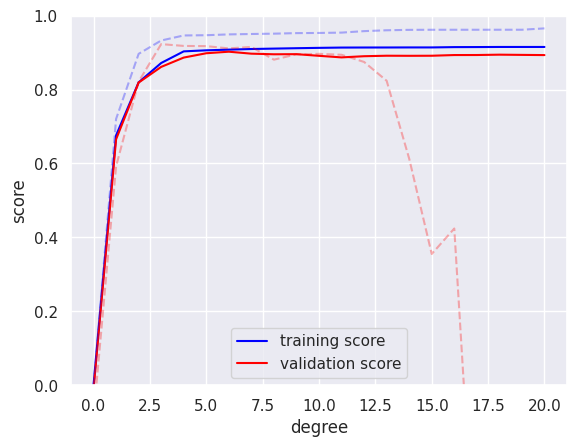

In [ ]:
degree = np.arange(21)
train_score2, val_score2 = validation_curve(PolynomialRegression(), X2, y2,
                                            param_name='polynomialfeatures__degree', param_range=degree, cv=7)

plt.plot(degree, np.median(train_score2, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score2, 1), color='red', label='validation score')
plt.plot(degree, np.median(train_score, 1), color='blue', alpha=0.3, linestyle='dashed')
plt.plot(degree, np.median(val_score, 1), color='red', alpha=0.3, linestyle='dashed')
plt.legend(loc='lower center')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

Learning curves in Scikit-Learn



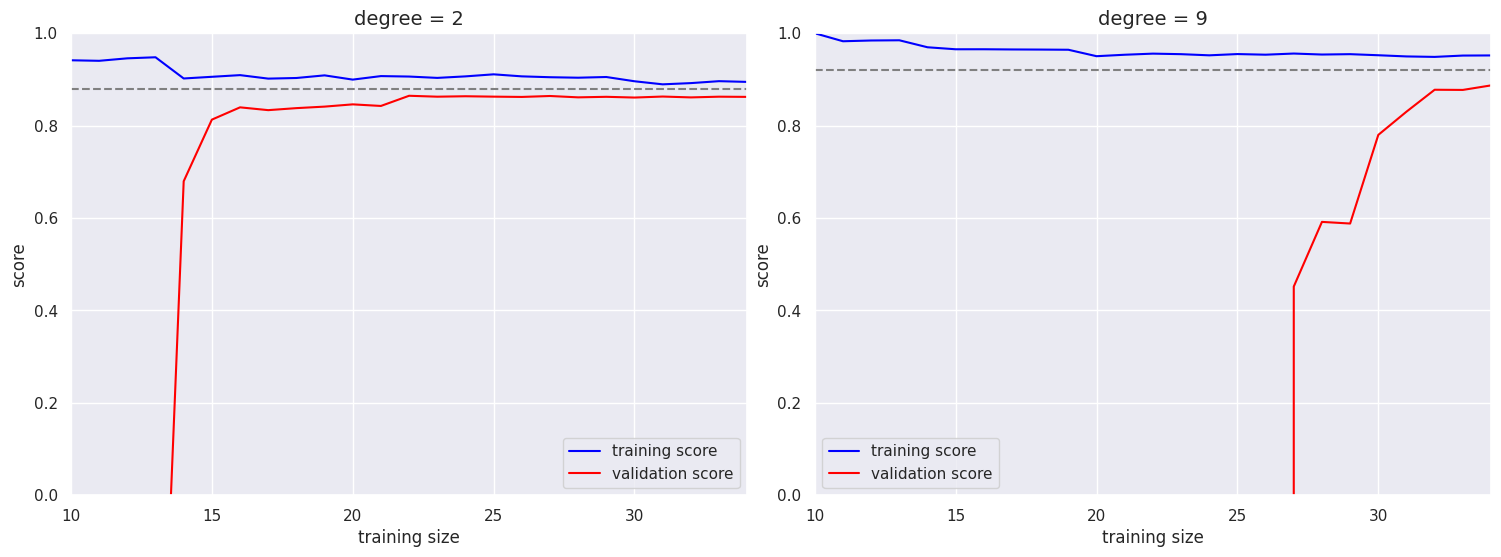

In [ ]:
from sklearn.model_selection import learning_curve

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for i, degree in enumerate([2, 9]):
    N, train_lc, val_lc = learning_curve(PolynomialRegression(degree),
                                         X, y, cv=7,
                                         train_sizes=np.linspace(0.3, 1, 25))

    ax[i].plot(N, np.mean(train_lc, 1), color='blue', label='training score')
    ax[i].plot(N, np.mean(val_lc, 1), color='red', label='validation score')
    ax[i].hlines(np.mean([train_lc[-1], val_lc[-1]]), N[0], N[-1],
                 color='gray', linestyle='dashed')

    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(N[0], N[-1])
    ax[i].set_xlabel('training size')
    ax[i].set_ylabel('score')
    ax[i].set_title('degree = {0}'.format(degree), size=14)
    ax[i].legend(loc='best')

Validation in Practice: Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'polynomialfeatures__degree': np.arange(21),
              'linearregression__fit_intercept': [True, False]}

grid = GridSearchCV(PolynomialRegression(), param_grid, cv=7)

In [ ]:
grid.fit(X, y);

In [ ]:
grid.best_params_

{'linearregression__fit_intercept': False,
 'polynomialfeatures__degree': np.int64(4)}

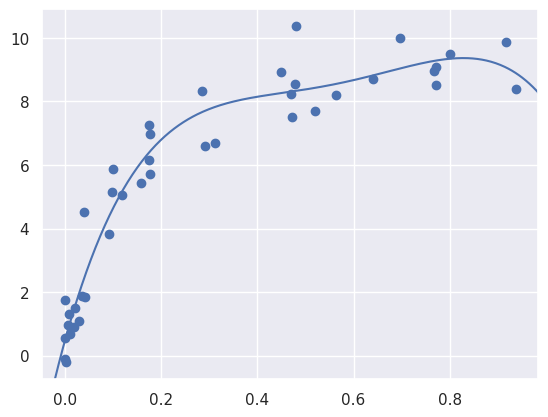

In [ ]:
model = grid.best_estimator_

plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = model.fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test);
plt.axis(lim);

### Feature Engineering

Categorical Features

In [ ]:
data = [
    {'price': 850000, 'rooms': 4, 'neighborhood': 'Queen Anne'},
    {'price': 700000, 'rooms': 3, 'neighborhood': 'Fremont'},
    {'price': 650000, 'rooms': 3, 'neighborhood': 'Wallingford'},
    {'price': 600000, 'rooms': 2, 'neighborhood': 'Fremont'}
]

In [ ]:
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer(sparse=False, dtype=int)
vec.fit_transform(data)

array([[     0,      1,      0, 850000,      4],
       [     1,      0,      0, 700000,      3],
       [     0,      0,      1, 650000,      3],
       [     1,      0,      0, 600000,      2]])

In [ ]:
vec.get_feature_names_out()

array(['neighborhood=Fremont', 'neighborhood=Queen Anne',
       'neighborhood=Wallingford', 'price', 'rooms'], dtype=object)

In [ ]:
vec = DictVectorizer(sparse=True, dtype=int)
vec.fit_transform(data)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (4, 5)>

Text Features

In [ ]:
sample = ['problem of evil',
          'evil queen',
          'horizon problem']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(sample)
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (3, 5)>

In [ ]:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,1,0,1,1,0
1,1,0,0,0,1
2,0,1,0,1,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer()
X = vec.fit_transform(sample)
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,0.517856,0.000000,0.680919,0.517856,0.000000
1,0.605349,0.000000,0.000000,0.000000,0.795961
2,0.000000,0.795961,0.000000,0.605349,0.000000


Image Features

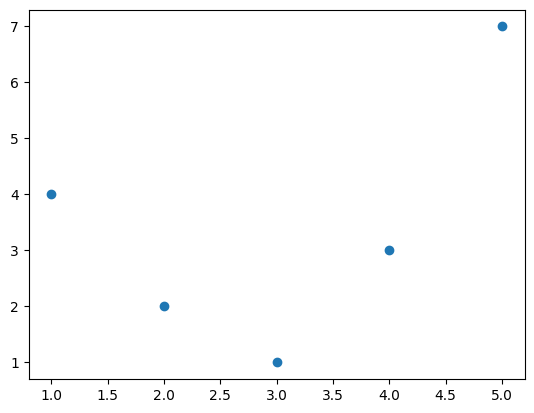

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5])
y = np.array([4, 2, 1, 3, 7])
plt.scatter(x, y);

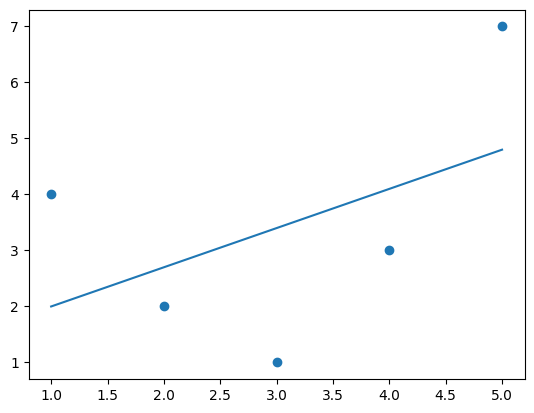

In [ ]:
from sklearn.linear_model import LinearRegression
X = x[:, np.newaxis]
model = LinearRegression().fit(X, y)
yfit = model.predict(X)
plt.scatter(x, y)
plt.plot(x, yfit);

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
X2 = poly.fit_transform(X)
print(X2)

[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]]


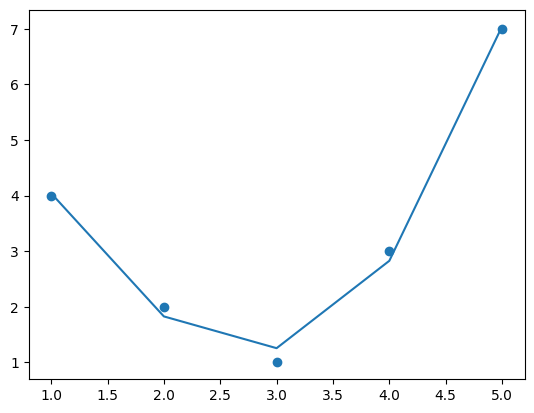

In [ ]:
model = LinearRegression().fit(X2, y)
yfit = model.predict(X2)
plt.scatter(x, y)
plt.plot(x, yfit);

Imputation of Missing Data

In [ ]:
from numpy import nan
X = np.array([[ nan, 0,   3  ],
              [ 3,   7,   9  ],
              [ 3,   5,   2  ],
              [ 4,   nan, 6  ],
              [ 8,   8,   1  ]])
y = np.array([14, 16, -1,  8, -5])

In [ ]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean')
X2 = imp.fit_transform(X)
X2

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

In [ ]:
model = LinearRegression().fit(X2, y)
model.predict(X2)

array([13.14869292, 14.3784627 , -1.15539732, 10.96606197, -5.33782027])

Feature Pipelines

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model = make_pipeline(SimpleImputer(strategy='mean'),
                      PolynomialFeatures(degree=2),
                      LinearRegression())

In [ ]:
model.fit(X, y)  # X with missing values, from above
print(y)
print(model.predict(X))

[14 16 -1  8 -5]
[14. 16. -1.  8. -5.]


### In Depth: Naive Bayes Classification:

Bayesian Classification

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

Gaussian Naive Bayes

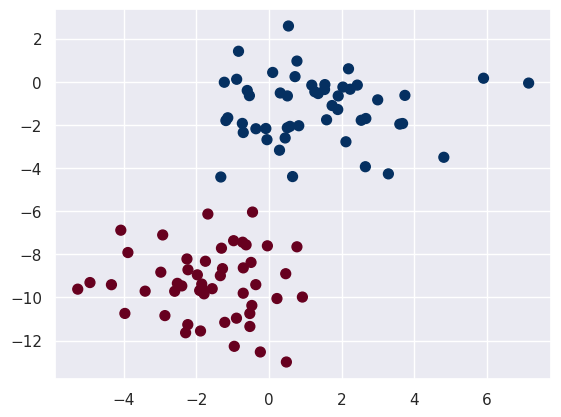

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');


In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X, y);

In [ ]:
rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)
ynew = model.predict(Xnew)

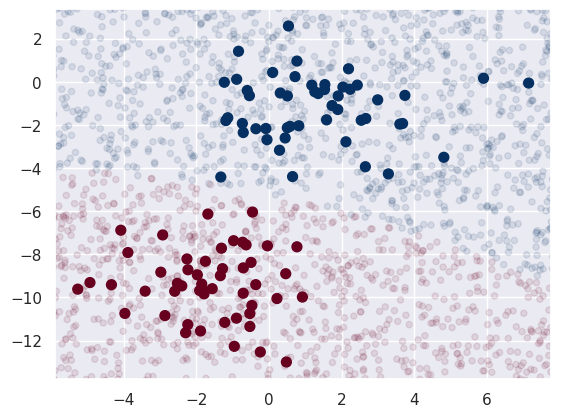

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
plt.axis(lim);

In [ ]:
yprob = model.predict_proba(Xnew)
yprob[-8:].round(2)

array([[0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])

Multinomial Naive Bayes

In [ ]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [ ]:
categories = ['talk.religion.misc', 'soc.religion.christian',
              'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

In [ ]:
print(train.data[5])

From: dmcgee@uluhe.soest.hawaii.edu (Don McGee)
Subject: Federal Hearing
Originator: dmcgee@uluhe
Organization: School of Ocean and Earth Science and Technology
Distribution: usa
Lines: 10


Fact or rumor....?  Madalyn Murray O'Hare an atheist who eliminated the
use of the bible reading and prayer in public schools 15 years ago is now
going to appear before the FCC with a petition to stop the reading of the
Gospel on the airways of America.  And she is also campaigning to remove
Christmas programs, songs, etc from the public schools.  If it is true
then mail to Federal Communications Commission 1919 H Street Washington DC
20054 expressing your opposition to her request.  Reference Petition number

2493.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

In [ ]:
model.fit(train.data, train.target)
labels = model.predict(test.data)

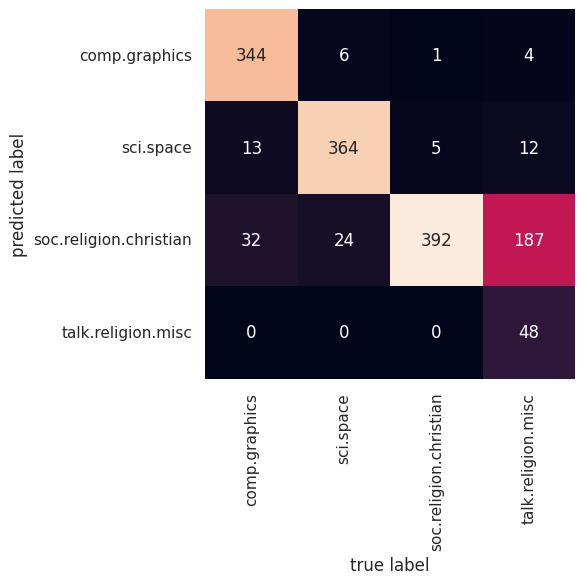

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [ ]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

In [ ]:
predict_category('God')

'soc.religion.christian'

In [ ]:
predict_category('sending a payload to the ISS')

'sci.space'

In [ ]:
predict_category('discussing islam vs atheism')

'soc.religion.christian'

In [ ]:
predict_category('determining the screen resolution')

'comp.graphics'

## Codigos de cisco

In [ ]:
from google.colab import files
uploaded = files.upload()

### Skeletal Variation

Project extensions

Below are a few ideas for extensions.

1. Which bird has the fewest neck vertebra?

	- Find the row with the minimum number of neck vertebrae.

2. Do humans have more bones in the arms or legs?

	- Filter the rows where the region is `arm`.
	- Repeat with `leg`.

3. How many ribs to humans have?

	- Filter the rows where the name contains the word `rib`.

		- Hint: `name.str.contains("rib")`.

	- To count the number of rows, use the dataframe function `df.shape`.

	- This will return the number of rows and columns in the dataframe.

Respuestas

1. Encuentra el ave con la menor cantidad de vértebras cervicales

Identifica la especie de ave que tiene el número mínimo de vértebras cervicales en el DataFrame 'birds'.


In [ ]:
import pandas as pd
birds = pd.read_csv('bird-neck-bones.csv')
min_vertebrae = birds['neck_vertebrae'].min()
birds.query('neck_vertebrae == @min_vertebrae')

,species,neck_vertebrae
11,blue-and-yellow macaw,10


el ave con mayor cantidad de huesos de vertebras cervicales es el guacamayo azul y amarillo

2. Comparar los huesos del brazo y la pierna humanos

Calcula y compara el número de huesos en los brazos y las piernas humanas usando el DataFrame 'df'.

In [ ]:
import pandas as pd
df = pd.read_csv('adult-human-skeleton.csv')

arm_bones = len(df.query('region == "arm"'))
print(f"Number of bones in human arms: {arm_bones}")

leg_bones = len(df.query('region == "leg"'))
print(f"Number of bones in human legs: {leg_bones}")

Number of bones in human arms: 6
Number of bones in human legs: 8


A partir del resultado, podemos ver que los brazos humanos tienen 6 huesos y las piernas humanas tienen 8 huesos. Por lo tanto, los humanos tienen más huesos en las piernas que en los brazos.

3. Cuenta las costillas humanas

Determina el número total de costillas humanas filtrando el DataFrame 'df' para los huesos que contengan 'costilla' en su nombre.


In [ ]:
rib_bones = df[df['name'].str.contains('rib')]
num_ribs = rib_bones.shape[0]
print(f"Number of human ribs: {num_ribs}")

Number of human ribs: 24


como se puede ver, el cuerpo humano tiene un total de 24 costillas

### Our World Connected

Project extensions

The file `extension-internet-users-by-continent.csv` provides data on the number of internet users across each continent, while the file `extension-historical-population-by-continent.csv` details historical population counts for each continent.

Here are some suggested extensions for your project:

1. Determine the year when more than 50% of the population in a continent of your choice first gained internet access.

2. Explore and analyze internet usage and population data for a specific region or country of interest, such as by sourcing information from sites like ourworldindata.org.

In [ ]:
population_by_continent = pd.read_csv('extension-historical-population-by-continent.csv')
population_by_continent

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
1587,South America,2021,428331420
1588,South America,2022,430492814
1589,South America,2023,433024230


In [ ]:
internet_users_by_continent = pd.read_csv('extension-internet-users-by-continent.csv')
internet_users_by_continent

,continent,year,internet_users
0,Africa,1990,0.000000e+00
1,Africa,1991,5.537650e+03
2,Africa,1992,1.649741e+04
...,...,...,...
189,South America,2019,2.815900e+08
190,South America,2020,3.102178e+08
191,South America,2021,3.177395e+08


In [ ]:
internet_users_by_continent.head()

,continent,year,internet_users
0,Africa,1990,0.0000
1,Africa,1991,5537.6504
2,Africa,1992,16497.4120
3,Africa,1993,49863.2200
4,Africa,1994,114298.6950


In [ ]:
internet_users_by_continent['continent'].unique()

array(['Africa', 'Asia', 'Europe', 'North America', 'Oceania',
       'South America'], dtype=object)

In [ ]:
population_by_continent.head()

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
3,Africa,-7000,1563759
4,Africa,-6000,1874767


In [ ]:
population_by_continent['continent'].unique()

array(['Africa', 'Asia', 'Europe', 'North America', 'Oceania',
       'South America'], dtype=object)

In [ ]:
internet_users_by_continent_grouped = internet_users_by_continent.groupby("continent").sum()
internet_users_by_continent_grouped

,year,internet_users
continent,,
Africa,64176,3.765887e+09
Asia,64176,2.436349e+10
Europe,64176,9.642364e+09
North America,64176,7.490076e+09
Oceania,64176,4.701009e+08
South America,64176,3.554876e+09


In [ ]:
internet_users_by_continent_africa = internet_users_by_continent[internet_users_by_continent['continent'] == 'Africa']
internet_users_by_continent_africa

,continent,year,internet_users
0,Africa,1990,0.000000e+00
1,Africa,1991,5.537650e+03
2,Africa,1992,1.649741e+04
...,...,...,...
29,Africa,2019,4.376317e+08
30,Africa,2020,5.130481e+08
31,Africa,2021,5.532078e+08


In [ ]:
mask = (internet_users_by_continent["continent"] == "Africa") & (internet_users_by_continent["year"] == 2020)
mask

,0
0,False
1,False
2,False
...,...
189,False
190,False
191,False


In [ ]:
population_by_continent_grouped = population_by_continent.groupby("continent").sum()
population_by_continent

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
1587,South America,2021,428331420
1588,South America,2022,430492814
1589,South America,2023,433024230


In [ ]:
population_by_continent_africa = population_by_continent[population_by_continent['continent'] == 'Africa']
population_by_continent_africa

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
262,Africa,2021,1413753270
263,Africa,2022,1446883817
264,Africa,2023,1480770740


In [ ]:
mask = (population_by_continent["continent"] == "Africa") & (population_by_continent["year"] == 2020)
mask

,0
0,False
1,False
2,False
...,...
1587,False
1588,False
1589,False


In [ ]:
merge_df = internet_users_by_continent.merge(population_by_continent, on=['year', 'continent'], how='left')
merge_df.query("year == 2020")

,continent,year,internet_users,population
30,Africa,2020,5.130481e+08,1380821355
62,Asia,2020,2.603488e+09,4686811205
94,Europe,2020,6.368468e+08,750826495
126,North America,2020,4.857265e+08,598250660
158,Oceania,2020,3.377616e+07,44079302
190,South America,2020,3.102178e+08,426213551


### Naming colors

Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


Calcular porcentajes de color para cada idioma

Calcular el porcentaje de fichas de color para cada color en inglés, español y tsimane. Esto implica usar `value_counts(normalize=True)` en las columnas `english_color`, `spanish_color` y `tsimane_color` del DataFrame `df` y almacenar los resultados como nuevos DataFrames.

Para calcular el porcentaje de cada nombre de color para hablantes de inglés, español y tsimane, aplicaré `value_counts(normalize=True)` a las respectivas columnas de color, convertiré las Series resultantes en DataFrames y cambiaré el nombre de las columnas de porcentaje.



In [ ]:
english_percentages_df = df['english_color'].value_counts(normalize=True).reset_index()
english_percentages_df.columns = ['Color', 'English_Percentage']

spanish_percentages_df = df['spanish_color'].value_counts(normalize=True).reset_index()
spanish_percentages_df.columns = ['Color', 'Spanish_Percentage']

tsimane_percentages_df = df['tsimane_color'].value_counts(normalize=True).reset_index()
tsimane_percentages_df.columns = ['Color', 'Tsimane_Percentage']

print("English Color Percentages:")
print(english_percentages_df)
print("\nSpanish Color Percentages:")
print(spanish_percentages_df)
print("\nTsimane Color Percentages:")
print(tsimane_percentages_df)

English Color Percentages:
    Color  English_Percentage
0   green              0.2750
1    blue              0.2000
2  purple              0.1375
3    pink              0.1250
4  yellow              0.0625
5   brown              0.0625
6  orange              0.0500
7     red              0.0375
8   black              0.0250
9   white              0.0250

Spanish Color Percentages:
        Color  Spanish_Percentage
0       green              0.2750
1   lightblue              0.1375
2      purple              0.1375
3        pink              0.1000
4       white              0.0750
5         red              0.0500
6      orange              0.0500
7      yellow              0.0500
8       brown              0.0500
9        blue              0.0500
10      black              0.0250

Tsimane Color Percentages:
    Color  Tsimane_Percentage
0   green              0.2500
1    blue              0.1500
2  yellow              0.1375
3  purple              0.1250
4   white              0.1125

La siguiente tarea consiste en visualizar los porcentajes calculados mediante gráficos de barras horizontales para cada idioma. Usaré `matplotlib.pyplot` para crear tres gráficos de barras horizontales, uno para los porcentajes de color de cada idioma, asegurándome de que las etiquetas, los títulos y el diseño sean correctos para facilitar la lectura.


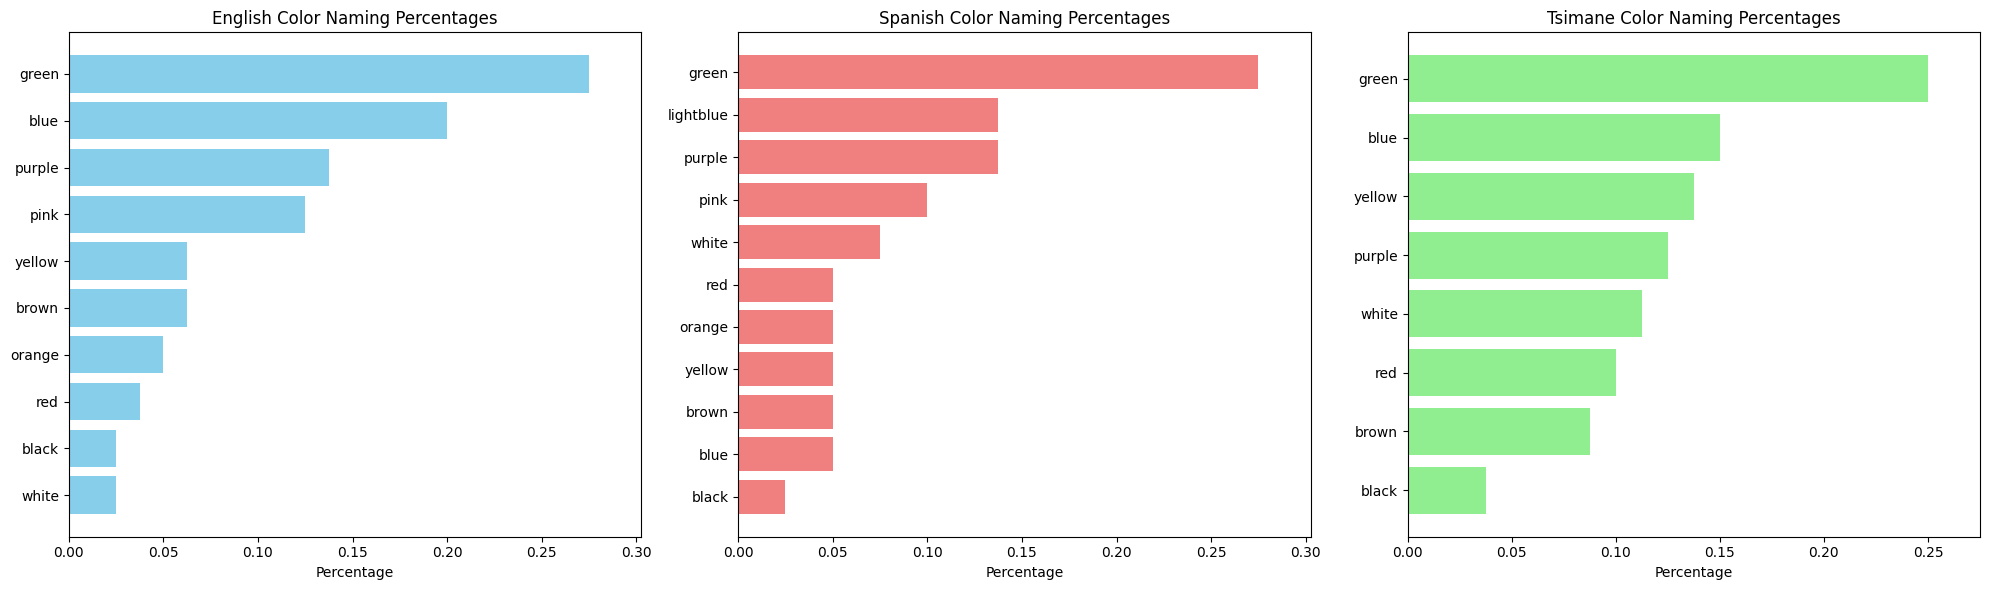

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# English Plot
axes[0].barh(english_percentages_df['Color'], english_percentages_df['English_Percentage'], color='skyblue')
axes[0].set_xlabel('Percentage')
axes[0].set_title('English Color Naming Percentages')
axes[0].set_xlim(0, max(english_percentages_df['English_Percentage']) * 1.1)
axes[0].invert_yaxis() # To have the highest percentage at the top

# Spanish Plot
axes[1].barh(spanish_percentages_df['Color'], spanish_percentages_df['Spanish_Percentage'], color='lightcoral')
axes[1].set_xlabel('Percentage')
axes[1].set_title('Spanish Color Naming Percentages')
axes[1].set_xlim(0, max(spanish_percentages_df['Spanish_Percentage']) * 1.1)
axes[1].invert_yaxis()

# Tsimane Plot
axes[2].barh(tsimane_percentages_df['Color'], tsimane_percentages_df['Tsimane_Percentage'], color='lightgreen')
axes[2].set_xlabel('Percentage')
axes[2].set_title('Tsimane Color Naming Percentages')
axes[2].set_xlim(0, max(tsimane_percentages_df['Tsimane_Percentage']) * 1.1)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

Para analizar la correlación entre idiomas, necesito fusionar los DataFrames de porcentaje. Empezaré fusionando los porcentajes de inglés y tsimane, luego los de inglés y español, y finalmente los de español y tsimane. Esto preparará los datos para la visualización del diagrama de dispersión.


In [ ]:
english_tsimane_correlation_df = pd.merge(english_percentages_df, tsimane_percentages_df, on='Color', how='outer').fillna(0)
english_spanish_correlation_df = pd.merge(english_percentages_df, spanish_percentages_df, on='Color', how='outer').fillna(0)
spanish_tsimane_correlation_df = pd.merge(spanish_percentages_df, tsimane_percentages_df, on='Color', how='outer').fillna(0)

print("English vs Tsimane Correlation Data:\n")
print(english_tsimane_correlation_df)
print("\nEnglish vs Spanish Correlation Data:\n")
print(english_spanish_correlation_df)
print("\nSpanish vs Tsimane Correlation Data:\n")
print(spanish_tsimane_correlation_df)

English vs Tsimane Correlation Data:

    Color  English_Percentage  Tsimane_Percentage
0   black              0.0250              0.0375
1    blue              0.2000              0.1500
2   brown              0.0625              0.0875
3   green              0.2750              0.2500
4  orange              0.0500              0.0000
5    pink              0.1250              0.0000
6  purple              0.1375              0.1250
7     red              0.0375              0.1000
8   white              0.0250              0.1125
9  yellow              0.0625              0.1375

English vs Spanish Correlation Data:

        Color  English_Percentage  Spanish_Percentage
0       black              0.0250              0.0250
1        blue              0.2000              0.0500
2       brown              0.0625              0.0500
3       green              0.2750              0.2750
4   lightblue              0.0000              0.1375
5      orange              0.0500              0.

Para visualizar la correlación entre pares de idiomas, crearé gráficos de dispersión para los porcentajes de inglés vs. tsimane, inglés vs. español, y español vs. tsimane, utilizando los DataFrames fusionados. Cada gráfico tendrá las etiquetas y títulos correspondientes.

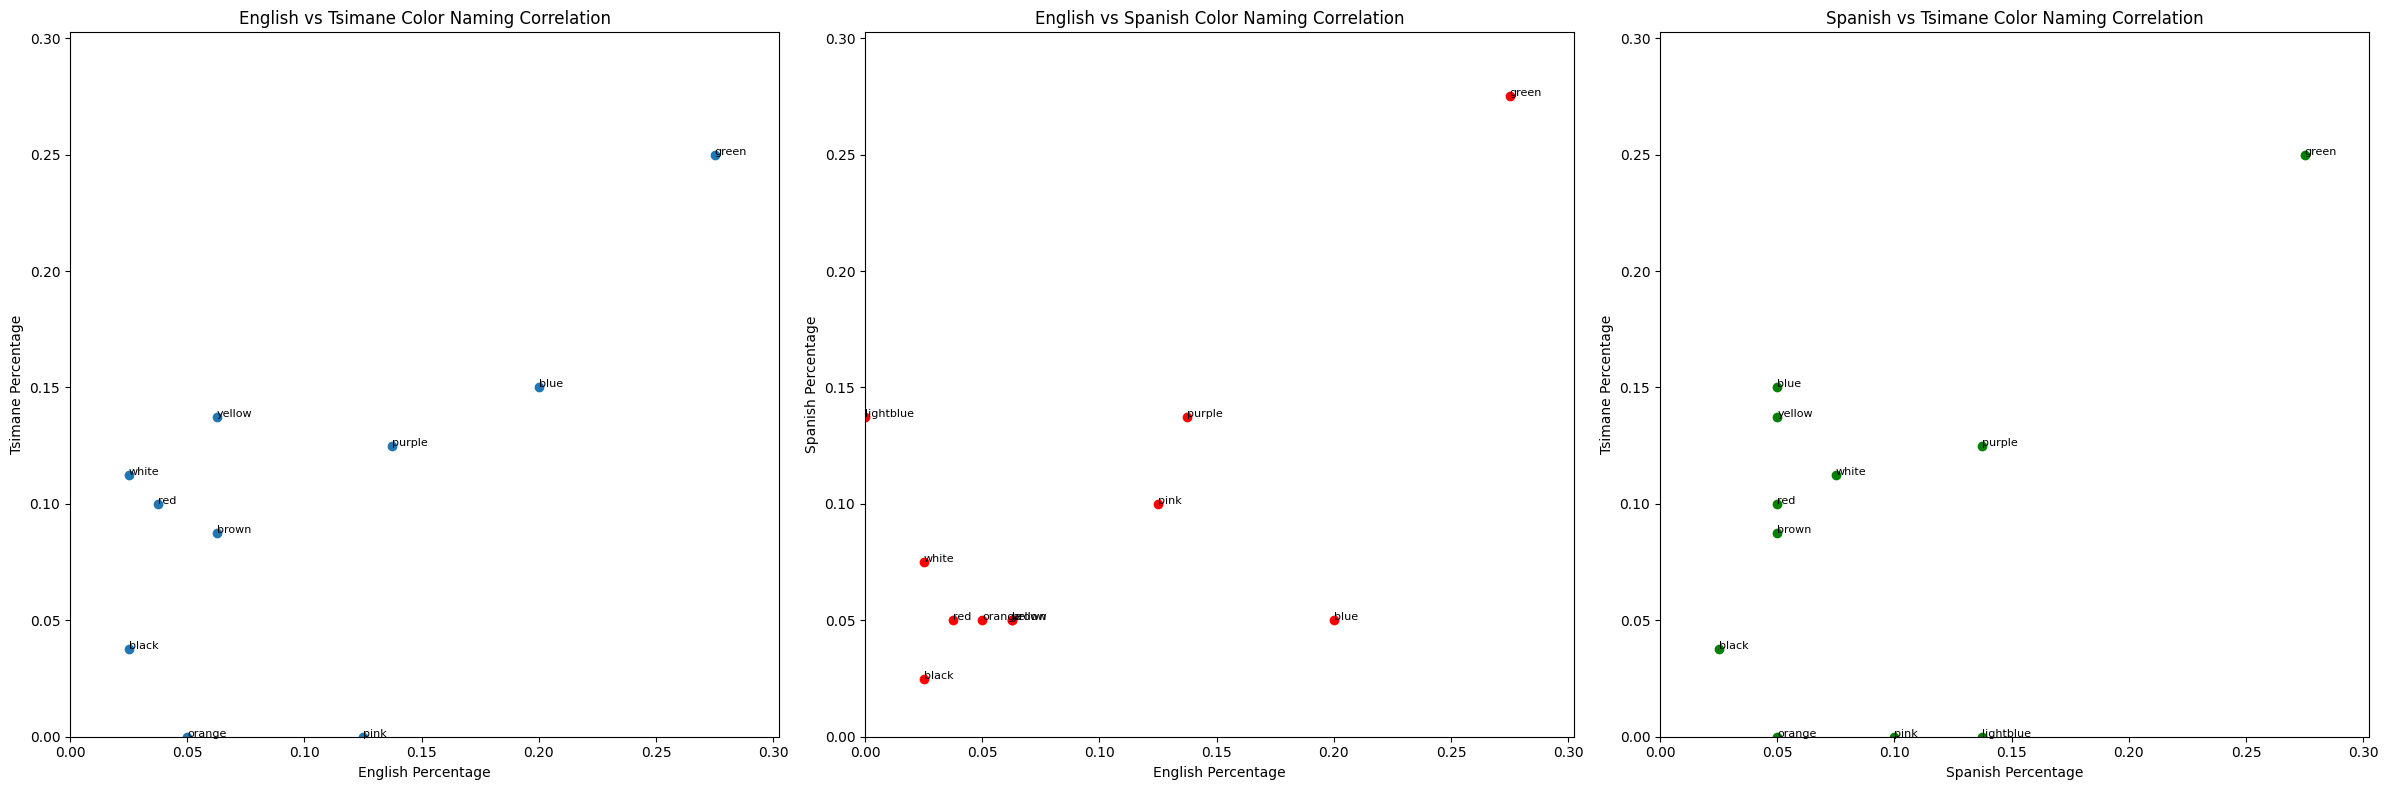

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# English vs Tsimane Scatter Plot
axes[0].scatter(english_tsimane_correlation_df['English_Percentage'], english_tsimane_correlation_df['Tsimane_Percentage'])
for i, txt in enumerate(english_tsimane_correlation_df['Color']):
    axes[0].annotate(txt, (english_tsimane_correlation_df['English_Percentage'][i], english_tsimane_correlation_df['Tsimane_Percentage'][i]), fontsize=8)
axes[0].set_xlabel('English Percentage')
axes[0].set_ylabel('Tsimane Percentage')
axes[0].set_title('English vs Tsimane Color Naming Correlation')
axes[0].set_xlim(0, max(english_tsimane_correlation_df['English_Percentage'].max(), english_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)
axes[0].set_ylim(0, max(english_tsimane_correlation_df['English_Percentage'].max(), english_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)

# English vs Spanish Scatter Plot
axes[1].scatter(english_spanish_correlation_df['English_Percentage'], english_spanish_correlation_df['Spanish_Percentage'], color='red')
for i, txt in enumerate(english_spanish_correlation_df['Color']):
    axes[1].annotate(txt, (english_spanish_correlation_df['English_Percentage'][i], english_spanish_correlation_df['Spanish_Percentage'][i]), fontsize=8)
axes[1].set_xlabel('English Percentage')
axes[1].set_ylabel('Spanish Percentage')
axes[1].set_title('English vs Spanish Color Naming Correlation')
axes[1].set_xlim(0, max(english_spanish_correlation_df['English_Percentage'].max(), english_spanish_correlation_df['Spanish_Percentage'].max()) * 1.1)
axes[1].set_ylim(0, max(english_spanish_correlation_df['English_Percentage'].max(), english_spanish_correlation_df['Spanish_Percentage'].max()) * 1.1)

# Spanish vs Tsimane Scatter Plot
axes[2].scatter(spanish_tsimane_correlation_df['Spanish_Percentage'], spanish_tsimane_correlation_df['Tsimane_Percentage'], color='green')
for i, txt in enumerate(spanish_tsimane_correlation_df['Color']):
    axes[2].annotate(txt, (spanish_tsimane_correlation_df['Spanish_Percentage'][i], spanish_tsimane_correlation_df['Tsimane_Percentage'][i]), fontsize=8)
axes[2].set_xlabel('Spanish Percentage')
axes[2].set_ylabel('Tsimane Percentage')
axes[2].set_title('Spanish vs Tsimane Color Naming Correlation')
axes[2].set_xlim(0, max(spanish_tsimane_correlation_df['Spanish_Percentage'].max(), spanish_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)
axes[2].set_ylim(0, max(spanish_tsimane_correlation_df['Spanish_Percentage'].max(), spanish_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)

plt.tight_layout()
plt.show()


In [ ]:
#cambia el nombre de la columna count por count_es
spanish_percentages_df = spanish_percentages_df.rename(columns={'Spanish_Percentage':'count_es'})
spanish_percentages_df

,Color,count_es
0,green,0.2750
1,lightblue,0.1375
2,purple,0.1375
3,pink,0.1000
4,white,0.0750
5,red,0.0500
6,orange,0.0500
7,yellow,0.0500
8,brown,0.0500
9,blue,0.0500


In [ ]:
#calcula el porcentaje de colores en Español
spanish_percentages_df['sp_color_percentage'] = spanish_percentages_df['count_es'] / spanish_percentages_df['count_es'].sum() * 100
spanish_percentages_df

,Color,count_es,sp_color_percentage
0,green,0.2750,27.50
1,lightblue,0.1375,13.75
2,purple,0.1375,13.75
3,pink,0.1000,10.00
4,white,0.0750,7.50
5,red,0.0500,5.00
6,orange,0.0500,5.00
7,yellow,0.0500,5.00
8,brown,0.0500,5.00
9,blue,0.0500,5.00


In [ ]:
#une los dataframes english_df y spanish_df y regresa los colores que existen en los dos dataframes.
corr_ing_esp = pd.merge(english_percentages_df, spanish_percentages_df, on='Color', how='inner')
corr_ing_esp


,Color,English_Percentage,count_es,sp_color_percentage
0,green,0.2750,0.2750,27.50
1,blue,0.2000,0.0500,5.00
2,purple,0.1375,0.1375,13.75
3,pink,0.1250,0.1000,10.00
4,yellow,0.0625,0.0500,5.00
5,brown,0.0625,0.0500,5.00
6,orange,0.0500,0.0500,5.00
7,red,0.0375,0.0500,5.00
8,black,0.0250,0.0250,2.50
9,white,0.0250,0.0750,7.50


### Art as Data


Project extensions

Here are some ideas for extending the project:

1. **Analyze painting dimensions over time**  
    
    Plot the length, width, or area of each painting against its creation date. Are there any noticeable trends or patterns?

2. **Track blue color usage over time**  
   - Compute the total area of each painting using data from `painting_info`.  

   - Identify features in the dataset where the color is 'blue'.

   - Calculate the area of these blue features.  

   - Group the blue feature areas by `painting_id` and sum them.

   - Merge this data with `painting_info`.  

   - Plot the percentage of blue in each painting over time.

   - Repeat with other colors (red, yellow, white, black, gray)

1. Calcular el área de la pintura

Agrega una nueva columna 'area' (ancho * alto) al DataFrame 'painting_info'. [eos]


**Razonamiento**:
Para calcular el área, multiplicaré las columnas 'width' y 'height' y asignaré el resultado a una nueva columna 'area' en el DataFrame `painting_info`. Luego, mostraré el DataFrame actualizado.


In [ ]:
painting_info['area'] = painting_info['width'] * painting_info['height']
painting_info

,painting_id,year,title,width,height,complexity,area
0,b104,1920,No. VI,1010,1007,41,1017070
1,b105,1920,Composition A,918,900,42,826200
2,b106,1920,Composition B,575,677,41,389275
3,b107,1920,Composition C,610,603,44,367830
4,b108,1920,Composition I,646,750,44,484500
...,...,...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052,31,1076196
132,b293,1939,"Composition of red, blue and white: II",330,435,26,143550
133,b294,1939,Trafalgar Square,1200,1452,62,1742400
134,b295,1939,Composition no. 8,681,752,47,512112


2. Trazar el Ancho de las Pinturas a lo Largo del Tiempo

Crea un diagrama de dispersión que muestre el 'ancho' de las pinturas frente a su 'año'.


**Razonamiento**:
Para visualizar el ancho de la pintura a lo largo del tiempo, crearé un diagrama de dispersión usando `matplotlib.pyplot` con 'year' en el eje x y 'width' en el eje y, y luego agregaré etiquetas y un título apropiados.


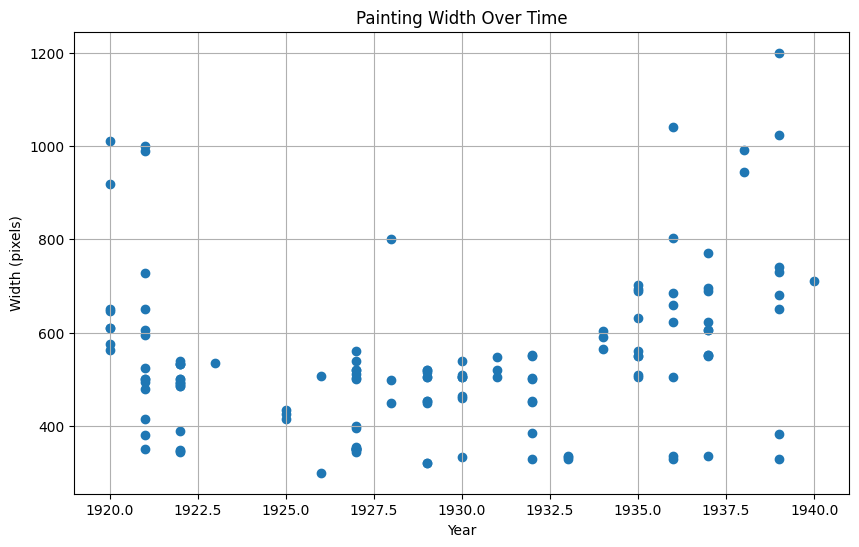

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(painting_info['year'], painting_info['width'])
plt.xlabel('Year')
plt.ylabel('Width (pixels)')
plt.title('Painting Width Over Time')
plt.grid(True)
plt.show()

**Razonamiento**:
Ahora que se ha trazado la anchura de la pintura a lo largo del tiempo, el siguiente paso es visualizar la altura de la pintura a lo largo del tiempo. Esto implica crear otro diagrama de dispersión utilizando las columnas 'year' y 'height' del DataFrame `painting_info`, añadiendo etiquetas y un título apropiados.


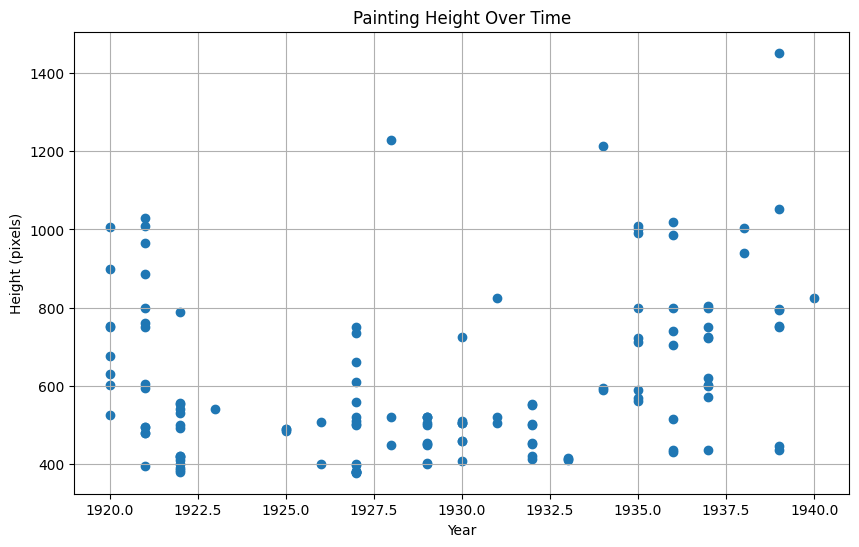

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(painting_info['year'], painting_info['height'])
plt.xlabel('Year')
plt.ylabel('Height (pixels)')
plt.title('Painting Height Over Time')
plt.grid(True)
plt.show()

**Razonamiento**:
Con los gráficos de ancho y altura completados, el siguiente paso lógico es visualizar el área de la pintura a lo largo del tiempo. Esto implica crear un diagrama de dispersión utilizando las columnas 'year' y la recién calculada 'area' del DataFrame `painting_info`, asegurando etiquetas adecuadas y un título para mayor claridad.


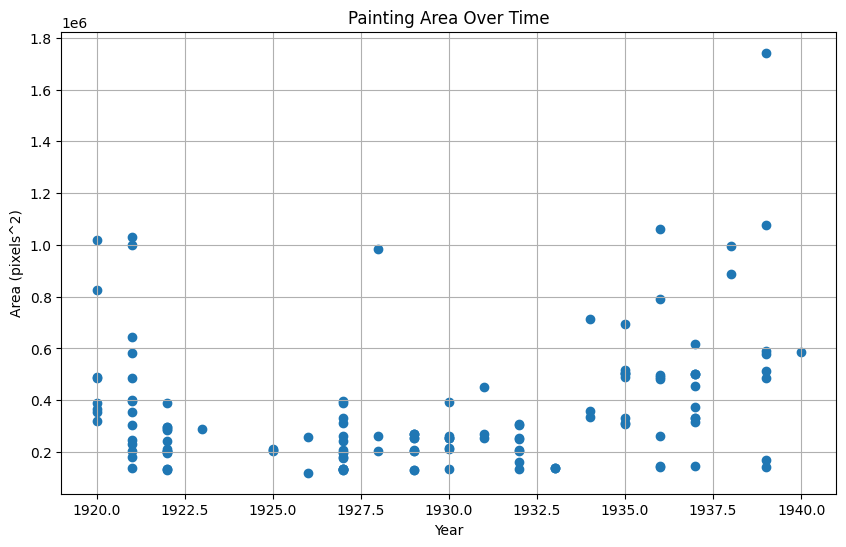

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(painting_info['year'], painting_info['area'])
plt.xlabel('Year')
plt.ylabel('Area (pixels^2)')
plt.title('Painting Area Over Time')
plt.grid(True)
plt.show()

**Razonamiento**:
Para calcular el porcentaje de cada color, primero necesito determinar el área de cada elemento individual (rectángulo o línea) dentro de una pintura. Esto implicará multiplicar las columnas 'width' y 'height' en el DataFrame `features` para crear una nueva columna 'feature_area'.



In [ ]:
features['feature_area'] = features['width'] * features['height']
features.head()

,painting_id,feature,x,y,width,height,color,rgb,feature_area
0,b104,rect,0,0,146,13,white,#ced2ca,1898
1,b104,rect,151,0,576,13,gray,#a4a7a7,7488
2,b104,rect,732,0,278,129,gray,#c8c9c7,35862
3,b104,rect,0,18,146,468,white,#cfd0ce,68328
4,b104,rect,151,18,107,111,black,#151d16,11877


**Razonamiento**:
Para calcular el área total de cada color dentro de cada pintura, agruparé el DataFrame `features` por 'painting_id' y 'color', y luego sumaré el 'feature_area' de cada grupo.


In [ ]:
color_areas = features.groupby(['painting_id', 'color'])['feature_area'].sum().reset_index()
color_areas.head()

,painting_id,color,feature_area
0,b104,black,171705
1,b104,blue,162204
2,b104,gray,274422
3,b104,red,150873
4,b104,white,123578


**Razonamiento**:
Para prepararme para calcular los porcentajes de color, necesito combinar el área total de cada color en `color_areas` con el área total de la pintura de `painting_info`. Esta combinación se realizará en la columna 'painting_id', utilizando una combinación izquierda para conservar toda la información de la pintura.

In [ ]:
color_percentage = pd.merge(color_areas, painting_info[['painting_id', 'area', 'year']], on='painting_id', how='left')
color_percentage.head()

,painting_id,color,feature_area,area,year
0,b104,black,171705,1017070,1920
1,b104,blue,162204,1017070,1920
2,b104,gray,274422,1017070,1920
3,b104,red,150873,1017070,1920
4,b104,white,123578,1017070,1920


**Razonamiento**:
Ahora que los datos combinados están disponibles, calcularé el porcentaje de cada color dividiendo el `feature_area` (área total de un color específico en una pintura) por el `area` total de la pintura, y guardaré esto como una nueva columna llamada `percentage` en el DataFrame `color_percentage`.

In [ ]:
color_percentage['percentage'] = (color_percentage['feature_area'] / color_percentage['area']) * 100
color_percentage.head()

,painting_id,color,feature_area,area,year,percentage
0,b104,black,171705,1017070,1920,16.882319
1,b104,blue,162204,1017070,1920,15.948165
2,b104,gray,274422,1017070,1920,26.981624
3,b104,red,150873,1017070,1920,14.834082
4,b104,white,123578,1017070,1920,12.150393


**Razonamiento**:
Para visualizar el porcentaje de cada color a lo largo del tiempo, crearé un único gráfico de dispersión, iterando a través de cada color único y trazando su porcentaje en función del año, usando diferentes colores para cada uno y agregando una leyenda para mayor claridad.

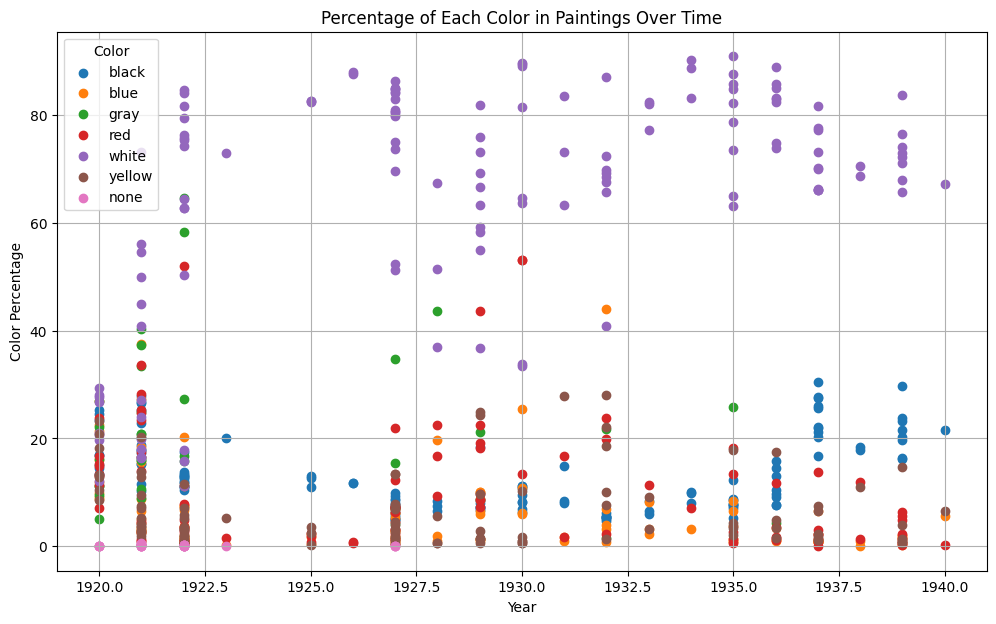

In [ ]:
plt.figure(figsize=(12, 7))
colors = color_percentage['color'].unique()

for color in colors:
    color_data = color_percentage[color_percentage['color'] == color]
    plt.scatter(color_data['year'], color_data['percentage'], label=color)

plt.xlabel('Year')
plt.ylabel('Color Percentage')
plt.title('Percentage of Each Color in Paintings Over Time')
plt.legend(title='Color')
plt.grid(True)
plt.show()

### What is the First Day of the Week?


Project Ideas

- How many territories show Friday, Saturday, Sunday, and Monday as the `first_day` of the week?

- How many people start the week on Friday, Saturday, Sunday, and Monday?
	- Hint: This will involve a `merge`.

- Which of the `four_regions` predominantly start the week on Sunday? On Monday? Are there any regions that are more divided between Sunday and Monday?
	- Hint: This will also involve a `merge`.

**Reasoning**:
To calculate the count of territories for each specified first day of the week, I will use the `value_counts()` method on the 'first_day' column of the `df` DataFrame and then filter for the requested days.



In [ ]:
first_day_counts = df['first_day'].value_counts()
selected_days = ['fri', 'sat', 'sun', 'mon']
territory_counts = first_day_counts[first_day_counts.index.isin(selected_days)]
print(territory_counts)

first_day
mon    186
sun     55
sat     15
fri      1
Name: count, dtype: int64


**Reasoning**:
First, I will merge the `df` and `pop` DataFrames on the 'alpha3' column to combine the first day of the week information with population data. Then, I will filter for the specified days ('fri', 'sat', 'sun', 'mon') and group the result by 'first_day' to sum the 'population' for each day.



In [ ]:
merged_df_pop = pd.merge(df, pop, on='alpha3', how='inner')

selected_days = ['fri', 'sat', 'sun', 'mon']
filtered_pop_df = merged_df_pop[merged_df_pop['first_day'].isin(selected_days)]

population_by_first_day = filtered_pop_df.groupby('first_day')['population'].sum()
print(population_by_first_day)

first_day
fri       0.50
mon    3600.19
sat     431.79
sun    3844.08
Name: population, dtype: float64
